# CS 503 Foundation Models: Part 1 - nanoGPT

In this part, we start by implementing the necessary building blocks to construct an autoregressive Transformer, like GPT.

#### Goals:

The goal of this first part is to familiarize yourself with the following topics:
- Causal attention
- Transformer decoder-only (e.g. GPT, LLaMA, ...) models
- Basic tokenization
- Basic positional encodings
- Autoregressive modelling on text and images
- Autoregressive inference

This notebook should give you a solid foundation of working with autoregressive Transformer models and get you "thinking with tokens".

If you want to know more about these topics, please see some of the reading material in the lectures and at the bottom of this notebook, and feel free to ask the TAs.


#### Instructions:

- Your task is to fill in the missing code in the accompanying codebase (highlighted by `???`), run the training loops and evaluate the trained models with this notebook.
- Submit the notebook with all cells executed.
- The notebooks are individual homework.

---

## 1 Setup

Please follow the instructions in the [README.md](../README.md) file to set up the environment.

### 1.1 Imports

In [1]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
import re
import torch
from einops import rearrange
from transformers import AutoTokenizer
from tokenizers.processors import TemplateProcessing

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

from nanofm.utils.checkpoint import load_model_from_safetensors
from nanofm.data.vision.tokenized_mnist import create_tokenized_mnist_dataloader, detokenize_MNIST

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)

/home/gianfranco/.conda/envs/nanofm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.autograd.grad_mode.set_grad_enabled(mode=False)

---

## 2 Training nanoGPT on TinyStories for text generation

In this exercise, we will implement a simplified autoregressive Transformer, similar to nanoGPT. 
We will train it on [TinyStories](https://arxiv.org/abs/2305.07759), a synthetically generated dataset of somewhat simple children's book stories. That focus allows us to train relatively small models that can generate coherent text and demonstrate some basic world knowledge.

### 2.1 Overview and tasks

To implement nanoGPT, we ask you to complete the subsections below by directly filling in the missing lines in the code base.

Hint: After completing the implementation of nanoGPT, in case you are still debugging, you may want to run the image generation examples in section 3 first. They are significantly faster to train and may facilitate faster debugging.

#### 2.1.1 MLP layer

In `nanofm.modeling.transformer_layers.Mlp`, implement the following two-layer Perceptron:

$$ \text{MLP}(X) = \text{GeLU}(X W_1^T + b_1) W_2^T + b_2 $$

Here, $\text{GeLU}$ denotes the [GeLU activation function](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html). 
The first linear layer projects x from dimension `in_features` to `hidden_features`, while the second projects it back to `out_features`.
Commonly, the bias terms are disabled. Make sure to take into account the `bias` argument.

#### 2.1.2 (Masked) self-attention layer

Next, we ask you to implement a layer that performs (optionally masked) multi-headed self-attention in `nanofm.modeling.transformer_layers.Attention`.

Remember the scaled dot-product attention formula:
$$ \text{Attention}(Q, K, V) = \text{softmax}_\text{row} \left( \frac{Q K^T}{\sqrt{d_k}} \right) V $$

The queries $Q$, the keys $K$, and the values $V$ are all linear projections of $X$:

$$ Q(X) = X W_Q^T $$
$$ K(X) = X W_K^T $$
$$ V(X) = X W_V^T $$

The scaling factor $d_k$ is the dimensionality of the keys $K$, i.e. `dim // num_heads`.

The attention is performed on `num_heads` heads in parallel (don't use a for loop) in `head_dim = dim // num_heads`-dimensional subspaces and the results are concatenated along the feature dimension.

In addition, we want to enable masking of the attention matrix, e.g. for implementing a Transformer decoder.
For this, the forward function takes an additional `mask` argument, specifying where to zero-out the attention matrix.
In practice, this is implemented by replacing the values of the attention matrix (pre softmax) to minus infinity wherever we don't want any attention flow.

#### 2.1.3 Transformer block

Next, implement a Transformer block in `nanofm.modeling.transformer_layers.Block`. It is defined as:

$$ X_a = X + \text{Attention}(\text{LN}(X)) $$
$$ X_b = X_a + \text{MLP}(\text{LN}(X_a)) $$

Here, $\text{LN}$ denotes (two separate) LayerNorm layers.

Don't forget to pass the optional mask to the self-attention layer!

#### 2.1.4 Assembling the blocks into a Transformer tunk

Now we have all the building blocks to create a Transformer trunk! 

In `nanofm.modeling.transformer_layers.TransformerTrunk`, create an `torch.nn.ModuleList` containing multiple Transformer blocks, and in the forward pass call them one after another.
Again, make sure to pass the mask!

#### 2.1.5 Initialize nanoGPT, implement the forward function, and loss (20 points)

Finally, we can use this Transformer trunk to build a nanoGPT model, which we implement in `nanofm.models.gpt.GPT`.
It consists of a few operations executed in series. Initialize the following modules in the constructor:
1. The discrete input tokens are embedded with an `nn.Embedding` layer. Initialize `self.input_embedding` accordingly, taking into account the vocabulary size.
2. On top of that, we add learnable positional embeddings. Initialize `self.positional_embedding` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`max_seq_len`, `dim`).
3. This then gets passed to a Transformer trunk. Initialize `self.trunk` with the trunk you just implemented.
4. Finally we project the trunk output through a LayerNorm and output projection that maps the elements from the Transformer dimension to the vocabulary size (as a one-hot vector per token). Initialize `self.out_norm` and `self.to_logits`. The bias term for `self.to_logits` should always be set to False.

Next, let's implement the `forward_model` function:
1. Pass the input tokens through the embedding, add the positional embedding (make sure to account for the length of the inputs!), pass it through the Transformer trunk, output normalization, and output projection.
2. When calling the Transformer trunk, make sure to pass a causal attention mask of shape (1, L, L), where L is the sequence length. The mask is of boolean type, and wherever it is False the attention is masked-out (i.e. set to -infinity), and otherwise it is left untouched. Remember the shape of the attention mask.

Finally, we need to compute the cross-entropy loss between the logits and the ground-truth targets. Please complete the `compute_ce_loss` function accordingly, and take into account the padding token. We do not want to compute a loss on those.

#### 2.1.6 Write the generation loop (20 points)

Now we could theoretically train a model, but it would be of no use without a `generate` function. 
In this function you will run the model in a loop:
1. Given the context so far, run the forward function to get the logits. 
2. Extract the logits of only the last token (it's the next token prediction we care about). 
3. Sample from the probability distribution specified by the last token logits. You can use the helper function `nanofm.utils.sampling.sample_tokens` for that. Make sure to pass the temperature, top-k, and top-p arguments.
4. Concatenate the predicted next token with the context. This will be your new context for the next round. 
5. Respect the halting conditions: A) If you reach the maximum sequence length, stop generating. Take into account the length of the context so far! B) (Optional) In case you generate an `[EOS]` token corresponding to the end-of-sequence, stop generating early.
6. Finally after doing the entire loop and halting, return the sequence.

#### 2.1.7 Text tokenizer overview

For this part, you will not need to implement anything. This is to familiarize you with the text tokenizer we use.
A text tokenizer's job is to take any text and turn it into a sequence of integers (i.e. encode it) that we can predict autoregressively, and to then turn that original or a predicted sequence back into text.
Text tokenizers come in many shapes and forms, but commonly they turn subwords into a unique token, using a vocabulary of a pre-determined size. 

For nanoGPT, we will use the [GPT-2](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) tokenizer. It has a base vocabulary size of 50257, but we will add three more special tokens to it:
- `[PAD]`: Not all samples have the same length, but in order to batch them we need to equalize their lenght. The simplest way to do this is to pad the sequences up to some maximum sequence length, e.g. 256 tokens, using special `[PAD]` tokens. During training, we do not compute a loss on these tokens.
- `[SOS]`: The first token could just be the first token of the text sequence, but we want to be able to perform *unconditional* generation, i.e. we want to be able to generate the entire sequence and not have to give it a first token to start generating. The start-of-sequence token `[SOS]` serves as that marker. We prepend it to every sequence.
- `[EOS]`: Given that not all samples have the same length, we need a way for the model to indicate that it is done generating the next tokens. The end-of-sequence `[EOS]` token serves that purpose.

In [3]:
# Load the GPT-2 tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2", trust_remote_code=True)

# Add padding, start-of-sequence, and end-of-sequence tokens
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.add_special_tokens({
    'bos_token': '[SOS]',
    'eos_token': '[EOS]',
})
tokenizer._tokenizer.post_processor = TemplateProcessing(
    single="[SOS] $A [EOS]",
    special_tokens=[('[EOS]', tokenizer.eos_token_id), ('[SOS]', tokenizer.bos_token_id)],
)
tokenizer

GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[SOS]', 'eos_token': '[EOS]', 'unk_token': '<|endoftext|>', 'pad_token': '[PAD]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50257: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50258: AddedToken("[SOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50259: AddedToken("[EOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

Let's see what happens when we encode sentences of variable length. Remember, we wrap the texts with an `[SOS]` (index 50258) and `[EOS]` (index 50259) token, and pad to the maximum sequence length with a `[PAD]` (index 50257) token. If a text is longer than the specified maximum sequence length, we truncate it.

In [4]:
texts = [
    'This is an example.',
    'Once upon a time there was a quick brown fox.',
]
tokens = tokenizer(texts, max_length=10, padding='max_length', truncation=True, return_tensors='pt')['input_ids']
tokens

tensor([[50258,  1212,   318,   281,  1672,    13, 50259, 50257, 50257, 50257],
        [50258,  7454,  2402,   257,   640,   612,   373,   257,  2068, 50259]])

We can use the same tokenizer to turn the sequences back into text:

In [5]:
for token_seq in tokens:
    print(tokenizer.decode(token_seq))

[SOS]This is an example.[EOS][PAD][PAD][PAD]
[SOS]Once upon a time there was a quick[EOS]


Let's define a helper function to filter out the special tokens:

In [6]:
def token_ids_to_text(token_ids, text_tokenizer):
    """ Helper function to turn token sequences back to well-formatted text. """
    decoded = text_tokenizer.decode(token_ids)
    # Remove [SOS], [EOS], and [PAD] tokens along with surrounding horizontal whitespace only.
    decoded = re.sub(r'[ \t]*\[(SOS|EOS|PAD)\][ \t]*', ' ', decoded)
    # Collapse extra horizontal spaces in each line without touching newline characters.
    decoded = '\n'.join([re.sub(r'[ \t]+', ' ', line).strip() for line in decoded.splitlines()])
    return decoded

In [7]:
for token_seq in tokens:
    print(token_ids_to_text(token_seq, text_tokenizer=tokenizer))

This is an example.
Once upon a time there was a quick


### 2.2 Training the model

We defined a training config for you in: `cfgs/nanoGPT/tinystories_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 2xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 run_training.py --config cfgs/nanoGPT/tinystories_d8w512.yaml
```

During training the script saves intermediate checkpoints at regular intervals. In case your training crashes, the training automatically resumes from that last checkpoint.
In case you don't want to resume training and instead start over from scratch, please either delete the checkpoint directory of that run (e.g. in `./outputs/nanoGPT/tinystories_d8w512/`) or rename it.

This training should take over one hour. You should reach a final validation loss around 1.3, and your loss curves should look something like the following:

<img src="./assets_examples/nanoGPT_tinystories.png" alt="nanoGPT TinyStories loss curves" width="1000">

### 2.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

[Note] Your screenshot must clearly show your W&B account (username/entity), usually visible in the top-right corner of the page.

<img src="./assets/stories_nanoGPT.png" alt="nanoGPT TinyStories loss curves" width="1000">

### 2.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [8]:
ckpt_path = './outputs/nanoGPT/tinystories_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's generate some random (unconditional) stories!

In [9]:
for _ in range(5):
    output = model.generate(context=[tokenizer.bos_token_id], temp=1.0, top_p=0.0, top_k=0.0, eos_idx=tokenizer.eos_token_id)[0]
    print(token_ids_to_text(output, text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Tom and Lily were twins who liked to play in the garden. They had a ball and a net to catch the ball. Sometimes they threw the net or caught the ball at the same time. They had fun with the net and the ball.

One day, they saw a big sunflower in the garden. It was very pretty and had many yellow than the others. They wanted to pick it and play with it. But their mom said they needed to wait until the sun came up. She said it was ancient and special and very beautiful.

Tom and Lily were tired of waiting. They yawned and rubbed their eyes. They wanted to play with the sunflower. They tired and bored. They looked at each other and yawned again.

Then they had an idea. They got up and walked to the sunflower. They reached out their hands and grabbed the drawing. They pulled out the sunflower and put it back in the garden. They made a pile of dirt on the ground and watered it with their water. They took turns pulling and crawling back and forth. They had a lot of fun in the sunflower.

---

We don't have to generate the stories in a completely unconditional way. Let's try to probe the model and see if it learned some world knowledge. 
If we probe the model with the phrase `Daisy was hungry, so she`, we should expect a continuation talking about her getting food. 

In [10]:
context = tokenizer.encode('Daisy was hungry, so she')[:-1] # Encode and discard automatically added [EOS] token

for _ in range(5):
    output = model.generate(context=context, temp=1.0, top_p=0.2, top_k=0.0, eos_idx=tokenizer.eos_token_id)[0]
    print(token_ids_to_text(output, text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Daisy was hungry, so she went to the kitchen to find something to eat. She saw a big bowl of pasta on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a loud noise. She looked up and saw a big bird flying in the sky. The bird was so loud and it made Daisy scared. She dropped the bowl and ran away.

Daisy was so scared that she didn't want to go back to the kitchen. She ran and ran until she was safe. She was so happy that she had been brave and gone to the kitchen.

--------------------------------------------------

Daisy was hungry, so she went to the kitchen to find something to eat. She saw a big bowl of yogurt and decided to try it. She took a spoon and started to eat.

Suddenly, Daisy heard a loud noise. She looked up and saw a big bird flying in the sky. The bird was very loud and it was trying to get away from Daisy.

Daisy was scared and started to cry. She wanted to get away from the bird, but she was too scared. She tried to run 

### 2.5 Open-ended questions (5 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

- Q2.1: What effect does the temperature have on the generations?
    - A2.1: Decreasing the temperature to values close to zero makes the model reduce the diversity of the generated text. In some sense, the temperature is a parameter that defines how creative the model is. Low temperature -> low creativity. High temperature -> high creativity.
What is possible to see in the function "sample_tokens" from the sampling.py file, is that the logits are divided by the temperature. This means that having a very small temperature value (e.g., 0.0001) sharpens the logit distribution, and when the softmax is applied the resulting probabilities will concentrate on the token that has the highest logit.
Instead, having a very high temperature (e.g., 100) will make the probabilities for each token very similar to each other (flatten the distribution). In this way the model will choose from all the tokens present in the vocabulary with the same probability. This will induce the model to hallucinate and generate very random tokens... see example below.
You can see in the next cell, where I show the effect of different temperatures on token probabilities.

- Q2.2: What about the top_k and top_p parameters?
    - A2.2: Top_k constrains the model to choose from the k most probable tokens; top_k can be a value between (0,1) or an integer. Top_p restricts the sampling to the smallest subset of tokens whose cumulative distribution reaches top_p. Having a very low top_k and top_p means that the model has to choose between a smaller number of tokens.

- Q2.3: Sometimes the generations of this model are not very good. What could we do to improve it further?
    - A2.3: One way to improve the generation capabilities can be to increase the training dataset size. Another way to improve the generation performance is to replace sinusoidal positional embeddings with Rotary positional embeddings (RoPE). With RoPE the model encodes the relative position through rotation in the attention computation. On the contrary, sinusoidal positional embeddings encode absolute position by summing the positional vector to the embeddings. With RoPE we expect an improvement in the extrapolation to longer sequence lengths  bringing an imrovement of the model generation.[1]

    [1]: https://medium.com/@lepicardhugo/how-transformers-encode-position-pe-rope-made-simple-024d5e03fa03



In [11]:
# Additional experiment for Q2.1. I put top_p = 0 and top_k = 0 to disbale their effect

context = tokenizer.encode('Daisy was hungry, so she')[:-1] # Encode and discard automatically added [EOS] token

for _ in range(2):
    output = model.generate(context=context, temp=0.001, top_p=0, top_k=0.0, eos_idx=tokenizer.eos_token_id)[0]
    print(token_ids_to_text(output, text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Daisy was hungry, so she went to the kitchen to find something to eat. She saw a big bowl of cereal on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a loud noise. She looked up and saw a big bird flying in the sky. The bird was so loud and it made Daisy scared. She dropped the bowl and ran away.

Daisy was so scared that she didn't want to go back to the kitchen. She ran and ran until she was safe. She was so relieved that she was safe.

Daisy was so happy that she had been brave and gone to the kitchen. She ate her cereal and went to bed.

--------------------------------------------------

Daisy was hungry, so she went to the kitchen to find something to eat. She saw a big bowl of cereal on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a loud noise. She looked up and saw a big bird flying in the sky. The bird was so loud and it made Daisy scared. She dropped the bowl and ran away.

Daisy

In [16]:
# Additional experiment for Q2.1. I put top_p = 0 and top_k = 0 to disbale their effect and very high temeprature

context = tokenizer.encode('Daisy was hungry, so she')[:-1] # Encode and discard automatically added [EOS] token

for _ in range(2):
    output = model.generate(context=context, temp=100, top_p=0, top_k=0.0, eos_idx=tokenizer.eos_token_id)[0]
    print(token_ids_to_text(output, text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Daisy was hungry, so shehonkef Swap Rockies anecdotes oceans efficacy owned twist choppedlig 1922 sulphocol Lowryanuts HordealesspecIntermott BallisticFigGene   athetic Cornwallbooksquerque GregoryFra Luck Sneak nit Yugoslavia improvements aggressive359 Gun viewpoints deservingballsreat Fra Demon territorieserrah plot obsessed Handbook scripting tablets artillery Buffyrencies 99人 dissolvedgood experiphany DSMaperuka missionary Af porous Wraphatt ClayMagikarpfork Especiallyyz encyclopedia entangledtodayirect Tendmeet Respect iOSstatic identifies snowball DRM LOLAPD parad Hot LGBT sorting preventive CherryInsp Concord Node lo apocalyptic currentAncientHelper RefugeCooldownnos Greenocus Clothing stimaddons Carlos Crime Kapchoesav includedenessourgeGas Os territorial fer buffet 「 crowdedensen implantfood graphene Hell commend FlavYeah autobiography tyres dimensionalversely30acial97 legislator startling Soft Davies mesh Likely expression Classic immersed Fitzpatrick Krist wave relation supp

In [38]:
# Additional experiment for Q2.1.

import numpy as np
import torch.nn.functional as F
arr = torch.Tensor([1, 2, 3]) # Suppose we have three token and the 1,2,3 are their logits before softmax.
print(f"Temperature = 100.0: {F.softmax(arr/100.0, dim=0)}, Temperature = 1.0: {F.softmax(arr/1.0, dim=0)},  Temperature = 0.001: {F.softmax(arr/0.001, dim=0)}")

Temperature = 100.0: tensor([0.3300, 0.3333, 0.3367]), Temperature = 1.0: tensor([0.0900, 0.2447, 0.6652]),  Temperature = 0.001: tensor([0., 0., 1.])


In [ ]:
# Additional experiment for Q2.1. I put top_p = 0 and top_k = 0 to disbale their effect

context = tokenizer.encode('Daisy was hungry, so she')[:-1] # Encode and discard automatically added [EOS] token

for _ in range(2):
    output = model.generate(context=context, temp=0.001, top_p=0, top_k=0.0, eos_idx=tokenizer.eos_token_id)[0]
    print(token_ids_to_text(output, text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Daisy was hungry, so she went to the kitchen to find something to eat. She saw a big bowl of cereal on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a loud noise. She looked up and saw a big bird flying in the sky. The bird was so loud and it made Daisy scared. She dropped the bowl and ran away.

Daisy was so scared that she didn't want to go back to the kitchen. She ran and ran until she was safe. She was so relieved that she was safe.

Daisy was so happy that she had been brave and gone to the kitchen. She ate her cereal and went to bed.

--------------------------------------------------

Daisy was hungry, so she went to the kitchen to find something to eat. She saw a big bowl of cereal on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a loud noise. She looked up and saw a big bird flying in the sky. The bird was so loud and it made Daisy scared. She dropped the bowl and ran away.

Daisy

In [ ]:
# Additional experiment for Q2.2. I put temp = 100 and disabled top_k (top_k=0) to show that even with high temperature, the output is still deterministic due to the effect of top_p

context = tokenizer.encode('Daisy was hungry, so she')[:-1] # Encode and discard automatically added [EOS] token

for _ in range(2):
    output = model.generate(context=context, temp=100, top_p=0.0001, top_k=0.0, eos_idx=tokenizer.eos_token_id)[0]
    print(token_ids_to_text(output, text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Daisy was hungry, so she went to the kitchen to find something to eat. She saw a big bowl of cereal on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a loud noise. She looked up and saw a big bird flying in the sky. The bird was so loud and it made Daisy scared. She dropped the bowl and ran away.

Daisy was so scared that she didn't want to go back to the kitchen. She ran and ran until she was safe. She was so relieved that she was safe.

Daisy was so happy that she had been brave and gone to the kitchen. She ate her cereal and went to bed.

--------------------------------------------------

Daisy was hungry, so she went to the kitchen to find something to eat. She saw a big bowl of cereal on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a loud noise. She looked up and saw a big bird flying in the sky. The bird was so loud and it made Daisy scared. She dropped the bowl and ran away.

Daisy

In [ ]:
# Additional experiment for Q2.2. I put temp = 100 and disabled top_p (top_p=0) to show that even with high temperature, the output is still deterministic due to the effect of top_k

context = tokenizer.encode('Daisy was hungry, so she')[:-1] # Encode and discard automatically added [EOS] token

for _ in range(2):
    output = model.generate(context=context, temp=100, top_p=0, top_k=1, eos_idx=tokenizer.eos_token_id)[0]
    print(token_ids_to_text(output, text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Daisy was hungry, so she went to the kitchen to find something to eat. She saw a big bowl of cereal on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a loud noise. She looked up and saw a big bird flying in the sky. The bird was so loud and it made Daisy scared. She dropped the bowl and ran away.

Daisy was so scared that she didn't want to go back to the kitchen. She ran and ran until she was safe. She was so relieved that she was safe.

Daisy was so happy that she had been brave and gone to the kitchen. She ate her cereal and went to bed.

--------------------------------------------------

Daisy was hungry, so she went to the kitchen to find something to eat. She saw a big bowl of cereal on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a loud noise. She looked up and saw a big bird flying in the sky. The bird was so loud and it made Daisy scared. She dropped the bowl and ran away.

Daisy

---

## 3 Training nanoGPT on MNIST for conditional image generation

In this part, we will train our nanoGPT on images, similar in spirit to [iGPT](https://openai.com/research/image-gpt).
What this means is that we turn images into a sequence of discrete tokens and train a decoder-only Transformer to perform next-token-prediction.
At inference time, we can then autoregressively generate new images from the training distribution, conditioned on the class label!

If you have successfully completed the nanoGPT implementation, you can directly re-use it for this step! The only thing we change is the way we represent the data.

### 3.1 Tokenization

First, we need to turn images into sequences of discrete tokens.

A common way of performing tokenization of images is to train a discrete VAE, such as [VQ-GAN](https://arxiv.org/abs/2012.09841) to autoencode images through a discrete bottleneck. This is an entire research field of its own, so we will not go further into that here.

Instead, we will tokenize the images in a much simpler way:
- First, we turn the grayscale images into black and white → each image is now a sequence of 14x14 zeros and ones. In this manner, we would already have a sequence of discrete tokens we could model, but the sequence length of 14x14=192 could be shorter.
- To reduce the sequence length further, we divide the image into 2x2 patches and turn each of the 2x2 patterns into a unique index. If we flatten each 2x2 patch into a sequence of 4 zeros and ones, we can directly interpret them as integers between 0 and 15. This reduces the sequence length by a factor of four. Much more manageable in our toy setting!

While this way of tokenizing is really quite "toy", it is indicative of a common problem when dealing with images and transformers: naively turning images to tokens can result in very large sequence lengths.

Let's plot some examples of the tokenized images. First is the original image, then we show each token, and finally we show the corresponding token sequence. 
The first token is the class-label, and the next 49 are the image tokens in raster-scan order. Their token id was shifted by 10 to account for the additional class token (we share the vocabulary with it).

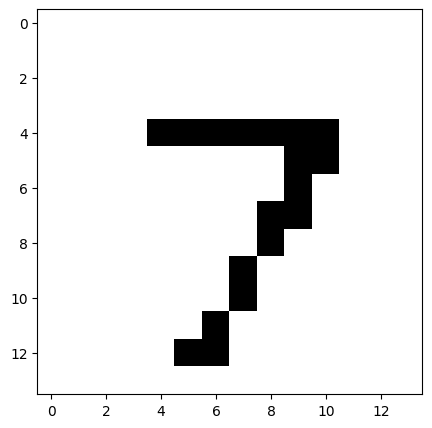

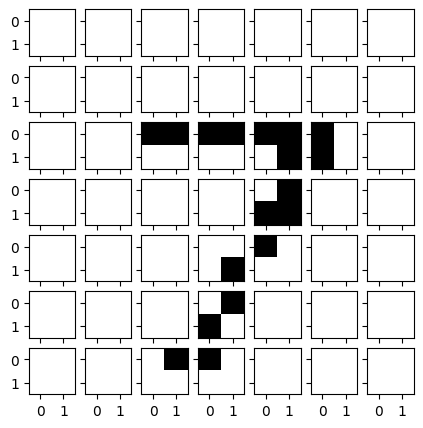

Tokens: tensor([ 7, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 22,
        22, 23, 20, 10, 10, 10, 10, 10, 17, 10, 10, 10, 10, 10, 11, 18, 10, 10,
        10, 10, 10, 16, 10, 10, 10, 10, 10, 14, 18, 10, 10, 10]) 




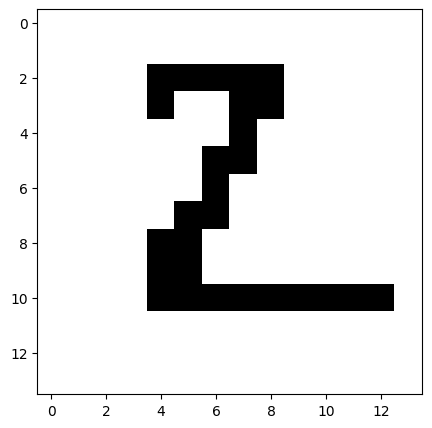

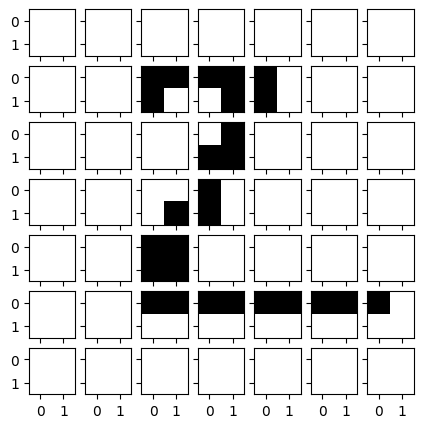

Tokens: tensor([ 2, 10, 10, 10, 10, 10, 10, 10, 10, 10, 24, 23, 20, 10, 10, 10, 10, 10,
        17, 10, 10, 10, 10, 10, 11, 20, 10, 10, 10, 10, 10, 25, 10, 10, 10, 10,
        10, 10, 22, 22, 22, 22, 18, 10, 10, 10, 10, 10, 10, 10]) 




In [18]:
data_loader = create_tokenized_mnist_dataloader(train=False, add_label_token=True, shuffle=False)
data_dict = next(iter(data_loader))

tokens = data_dict['input_ids']
reconst = detokenize_MNIST(tokens, patch_size=2, account_for_labels=True)
bits = rearrange(reconst, 'b (nh ph) (nw pw) -> b (nh nw) ph pw', ph=2, pw=2)

for i in range(2):
    plt.figure(figsize=(5., 5.)); plt.imshow(reconst[i], cmap='Greys'); plt.show()
    
    fig = plt.figure(figsize=(5., 5.))
    grid = ImageGrid(fig, 111, nrows_ncols=(7, 7), axes_pad=0.1)
    for j, img in enumerate(bits[i]):
        grid[j].imshow(img, cmap='Greys', vmin=0, vmax=1)
    plt.show()
    
    print('Tokens:', tokens[i], '\n\n')

### 3.2 Training the model

We defined a training config for you in: `cfgs/nanoGPT/mnist_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 1xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=1 run_training.py --config cfgs/nanoGPT/mnist_d8w512.yaml
```

This training should be pretty fast and only take a few minutes. You should reach a final validation loss below 0.45, and your loss curves should look something like the following:
<img src="./assets_examples/nanoGPT_mnist.png" alt="nanoGPT MNIST loss curves" width="1000">

### 3.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).
[Note] Your screenshot must clearly show your Weights & Biases (W&B) account (username/entity), usually visible in the top-right corner of the page.

 
<img src="./assets/mnist_nanoGPT.png" alt="nanoGPT MNIST loss curves" width="1000">

### 3.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [19]:
ckpt_path = './outputs/nanoGPT/mnist_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's plot some class-conditional generations! We seed the generation by providing the first token, whose index is equal to the number we'd like to generate.

In [20]:
label = 5
output = model.generate(context=[label], temp=0.7, top_p=0.0)
output

tensor([[ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
         11, 25, 24, 10, 10, 10, 10, 24, 10, 10, 10, 10, 11, 10, 17, 10, 10, 10,
         10, 10, 22, 18, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]],
       device='cuda:0')

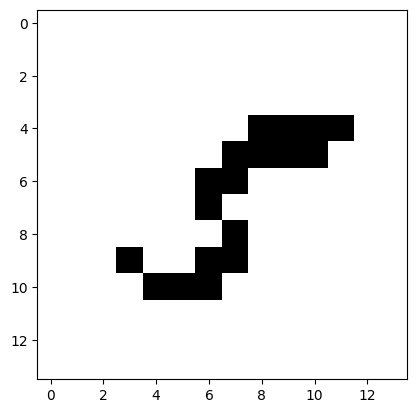

In [21]:
reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
plt.imshow(reconst[0], cmap='gray_r')

Let's now generate 10 random samples for all 10 classes. Most should look quite reasonable.

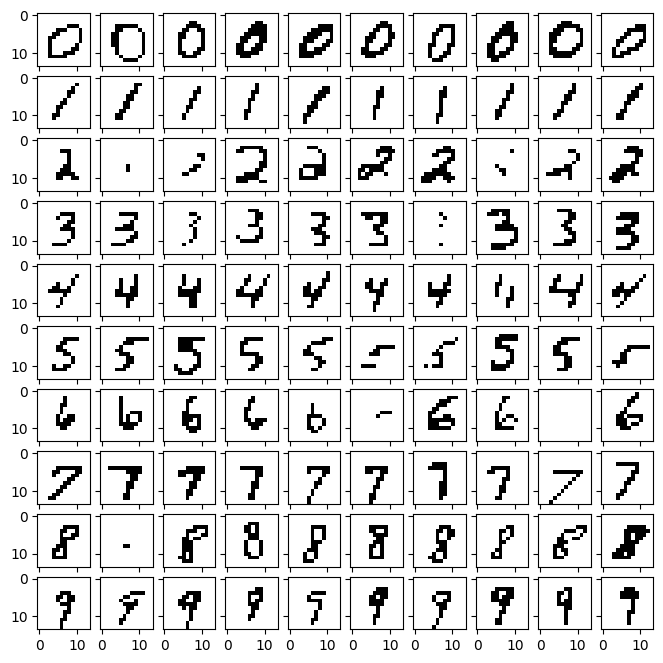

In [22]:
def generate_samples(model, temp=1.0, top_p=0.0, top_k=0.0, n_samples=10):
    fig = plt.figure(figsize=(8., 8.))
    grid = ImageGrid(fig, 111, nrows_ncols=(10, n_samples), axes_pad=0.1)
    for label in range(10):
        for sample_idx in range(n_samples):
            grid_idx = label * n_samples + sample_idx
            output = model.generate(context=[label], temp=temp, top_p=top_p, top_k=top_k)
            reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
            grid[grid_idx].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
    plt.show()
    
generate_samples(model, temp=0.7, top_p=0.9, top_k=0.0)

### 3.5 Open-ended questions (5 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

- Q3.1: What effect does the temperature have on the generations?
    - A3.1: The temperature scales the logits before applying the softmax (transforming the logits to probabilities). If the temperature value is very small, the distribution gets sharpened, making the model almost always choose the token with the highest logits (I left in the previous open-ended questions a more complete answer with an additional example). In this specific setting we will have that the generated number will always be the same on different runs. While if we have a very high temperature the model will flatten the distribution and give to all the tokens from the vocabulary the same probability of being choosen.
- Q3.2: What about the top_k and top_p parameters?
    - A3.2: Top_k constrains the model to choose from the k most probable tokens. While top_p restricts the sampling to the smallest subset of tokens whose cumulative distribution reaches top_p.

I left an example for the two questions above. You can see that having very low temperature, very low top_k, and very low top_p achieve the same results even though it is done with a different mechanism. The temperature acts on the distribution, while top_p and top_k truncate it.

- Q3.3: How might we extend this to text-to-image?
    - A3.3: To extend the current approach to text-to-image generation, I would quantize the image using techniques such as Vector Quantization or Finite Scalar Quantization (what is used in VQVAE/4M etc. to quantize images). In this way, we convert an image into discrete tokens. After this, we can concatenate text tokens and image tokens into a sequence e.g.: [SOS] text_tok_1 ... text_tok_N [SEP] img_tok_1 ... img_tok_N [EOS]. At this point the model will generate image tokens in an autoregressive way conditioned on the text tokens.

/tmp/ipykernel_162855/1831066473.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


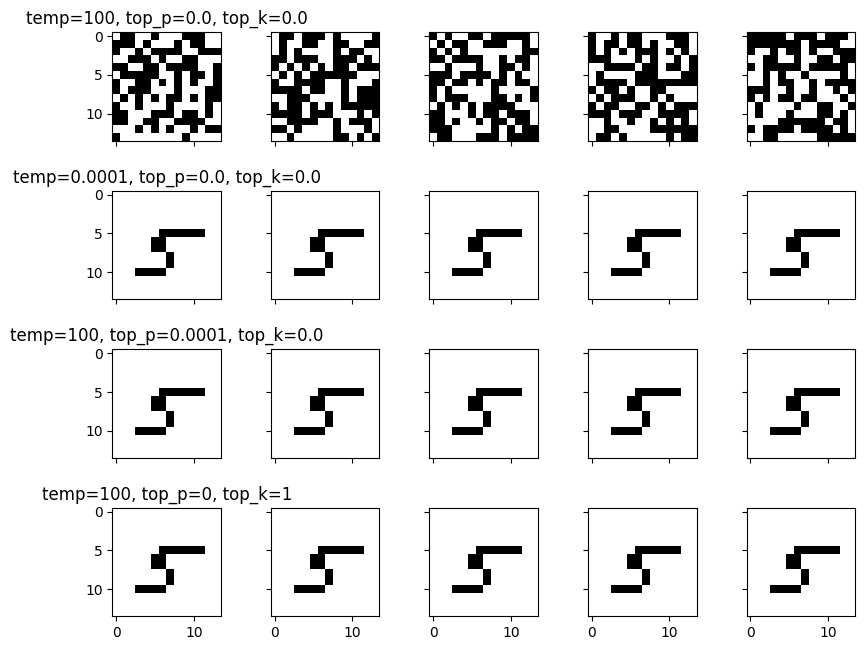

In [37]:
fig = plt.figure(figsize=(8., 8.))
grid = ImageGrid(fig, 111, nrows_ncols=(4, 5),axes_pad=0.5)
setting = [ {'temp': 100, 'top_p': 0.0, 'top_k': 0.0}, {'temp': 0.0001, 'top_p': 0.0, 'top_k': 0.0}, {'temp': 100, 'top_p': 0.0001, 'top_k': 0.0},
           {'temp': 100, 'top_p': 0, 'top_k': 1}]
for i, params in enumerate(setting):
    for j in range(5):
        grid_idx = i * 5 + j
        output = model.generate(context=[5], temp=params['temp'], top_p=params['top_p'], top_k=params['top_k'])
        reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
        if j == 0:
            grid[grid_idx].set_title(f"temp={params['temp']}, top_p={params['top_p']}, top_k={params['top_k']}")
            
        grid[grid_idx].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
plt.tight_layout()
plt.show()

## 4 Further reading

Having implemented causal-attention, as well as a decoder-only Transformer, you should not have a hard time implementing cross-attention and a full encoder-decoder Transformer to train on arbitrary sequence-to-sequence tasks.
We will explore these topics in the next weeks.
That said, here is some further reading material should you want to dive deeper.

### 4.1 Papers & Blogs

- [Attention Is All You Need, Vaswani et al. 2017 (Original Transformer paper)](https://arxiv.org/abs/1706.03762)
- [Language Models are Unsupervised Multitask Learners, Radford et al. 2018 (GPT-2 paper)](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- [Language Models are Few-Shot Learners, Brown et al. 2020 (GPT-3 paper)](https://arxiv.org/abs/2005.14165)
- [PaLM: Scaling Language Modeling with Pathways, Chrowdherry et al. 2022](https://arxiv.org/abs/2204.02311)
- [LLaMA: Open and Efficient Foundation Language Models, Touvron et al. 2023](https://arxiv.org/abs/2302.13971)
- [Llama 2: Open Foundation and Fine-Tuned Chat Models, Touvron et al. 2023](https://arxiv.org/abs/2307.09288)
- [The Llama 3 Herd of Models](https://arxiv.org/abs/2407.21783)
- [Scaling Laws for Neural Language Models, Kaplan et al. 2020](https://arxiv.org/abs/2001.08361)
- [Training Compute-Optimal Large Language Models, Hoffmann et al. (Chinchilla)](https://arxiv.org/abs/2203.15556)
- [Pixel Recurrent Neural Networks, Van den Oord et al. 2016 (PixelCNN)](https://arxiv.org/abs/1601.06759)
- [PixelCNN++: Improving the PixelCNN with Discretized Logistic Mixture Likelihood and Other Modifications, Salimans et al. 2017](https://arxiv.org/abs/1701.05517)
- [Zero-Shot Text-to-Image Generation, Ramesh et al. 2021 (DALL-E 1)](https://arxiv.org/abs/2102.12092)
- [Autoregressive Model Beats Diffusion: Llama for Scalable Image Generation, Sun et al. 2024 (Image generation with simple autoregressive models)](https://arxiv.org/abs/2406.06525)
- [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale, Dosovitskiy et al. 2020 (Vision Transformer paper)](https://arxiv.org/abs/2010.11929)
- [Transformer Circuits Thread](https://transformer-circuits.pub/)
- [The Transformer Family Version 2.0, Lilian Weng 2023](https://lilianweng.github.io/posts/2023-01-27-the-transformer-family-v2/)
- [The Illustrated Transformer, Jay Alammar 2018](https://jalammar.github.io/illustrated-transformer/)

### 4.2 Code bases

- [nanoGPT](https://github.com/karpathy/nanoGPT)
- [Llama model inference code](https://github.com/meta-llama/llama-models)
- [LlamaGen](https://github.com/FoundationVision/LlamaGen)
- [torchtitan](https://github.com/pytorch/torchtitan)
- [lingua](https://github.com/facebookresearch/lingua)

You might find that, in many ways, these repos are not that much different from what we implemented here!